In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**Step:1=Data Collection**

In [8]:
# Read the CSV Dataset
df = pd.read_csv('titanic_train.csv')

print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [9]:
#Checking for Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
#Stastistial Summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Step#2: Data Cleaning & Preprocessing**

In [11]:
#Handling Missing Values in Age with MEAN
df['Age']=df['Age'].fillna(df['Age'].median())

#Filling 1 missing value in fair with mediaan
df['Fare']=df['Fare'].fillna(df['Fare'].median())

df['Sex']=df["Sex"].fillna(df['Sex'].mode)




In [12]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
# Checking if there are Missing Value yet
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Step#3: Feature Engineering**

In [14]:
# Coverting Male/Female into Numbers 0/1
df['Sex']=df['Sex'].map({'male':0, 'female':1})

# One-hot Encoding of the Embarked Column
df=pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [15]:
# Creating FamilySize Feature
df['FamilySize']=df['SibSp'] + df['Parch'] + 1

In [16]:
# Extract text that ends with a period
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2456/372438020.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [17]:
# Group rare titles into "Rare" and standard ones into categories
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Now encode the Title
df['Title'] = pd.factorize(df['Title'])[0]

In [18]:
# We have extracted useful Information from Name. drop it and Ticket
df.drop(columns=['Name','Ticket'], inplace=True)

In [19]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

# Scaling the AGE and FARE specially
df[['Age','Fare']]=scaler.fit_transform(df[['Age','Fare']])

In [20]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked_Q,0


In [22]:
df.drop(columns=['Cabin'], inplace=True)

**Step#4: Model Training**

In [23]:
from sklearn.model_selection import train_test_split
# X is all Features except the Target Variable "Survived"
X=df.drop('Survived', axis=1)
y=df['Survived']

In [24]:
# Splitting Dataset into Train and Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Or, if you already split, run this on your test set
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

**Using LogisticRegression Model**

In [28]:
#Training the Model
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
#Evaluating the Model
from sklearn.metrics import accuracy_score
predictions=log_model.predict(X_test)
print(f"The Accuracy of Logistic Regression is: , {accuracy_score(y_test, predictions):.2%}")

The Accuracy of Logistic Regression is: , 78.77%


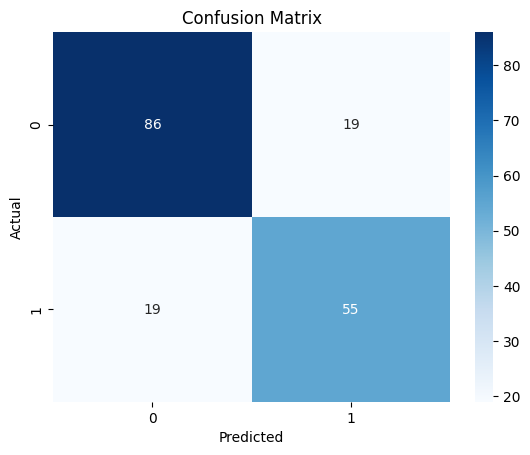

In [32]:
# Confusion Metrics of Logistic Regression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr=confusion_matrix(y_test, predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [34]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



**Using Random Forest**

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Training the Model
rf_model.fit(X_train, y_train)

#Predict from Model
rf_pred=rf_model.predict(X_test)
rf_acc=accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: , {rf_acc:.2%} ")

Random Forest Accuracy: , 82.12% 


Checking for Feature Importance in Random Forest

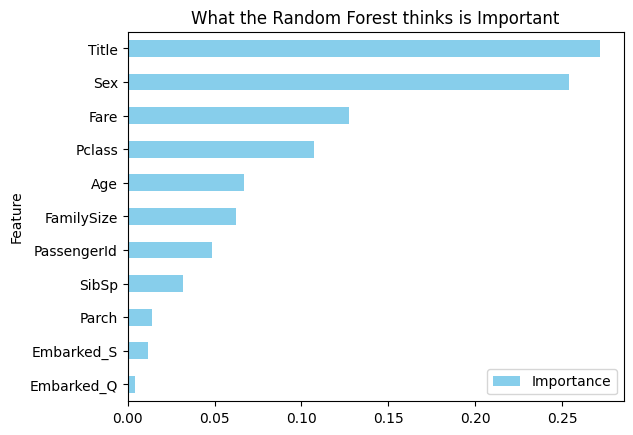

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance levels from the model
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and Plot
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
feature_importance_df.plot(kind='barh', x='Feature', y='Importance', color='skyblue')
plt.title('What the Random Forest thinks is Important')
plt.show()

In [40]:
#Training Accuracy
print(f"Train Score: {rf_model.score(X_train, y_train):.2%}")
print(f"Test Score: {rf_model.score(X_test, y_test):.2%}")

Train Score: 86.66%
Test Score: 82.12%


Cross-Validation on Random Forest

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"Average Cross-Validation Score: {scores.mean():.2%}")

Average Cross-Validation Score: 82.44%


Hyper Parameter Tuning using GridSearchCV

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.2%}")

Best Parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 83.14%


**K-Nearest Neighbour Algorithm**

In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(f"KNN Accuracy is: {knn.score(X_test, y_test): .2%}")


KNN Accuracy is:  58.10%


**Support Vector Machine (SVM) Algorithm**

In [49]:
from sklearn.svm import SVC
svm=SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)
print(f"SVM Accuracy: {svm.score(X_test, y_test):.2%}")

SVM Accuracy: 58.66%


In [ ]:
Standard Scaling the Input Features

In [51]:
#Scaling the Input Features for SVM
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_scaled = SVC(kernel='rbf', C=1.0)
svm_scaled.fit(X_train_scaled, y_train)

print(f"Scaled SVM Accuracy: {svm_scaled.score(X_test_scaled, y_test):.2%}")

Scaled SVM Accuracy: 83.24%


**Using Naive Bayes Model**

In [53]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(X_train, y_train)

print(f"Naive Bayes Accuracy: {nb_model.score(X_test, y_test):.2%}")


Naive Bayes Accuracy: 77.09%


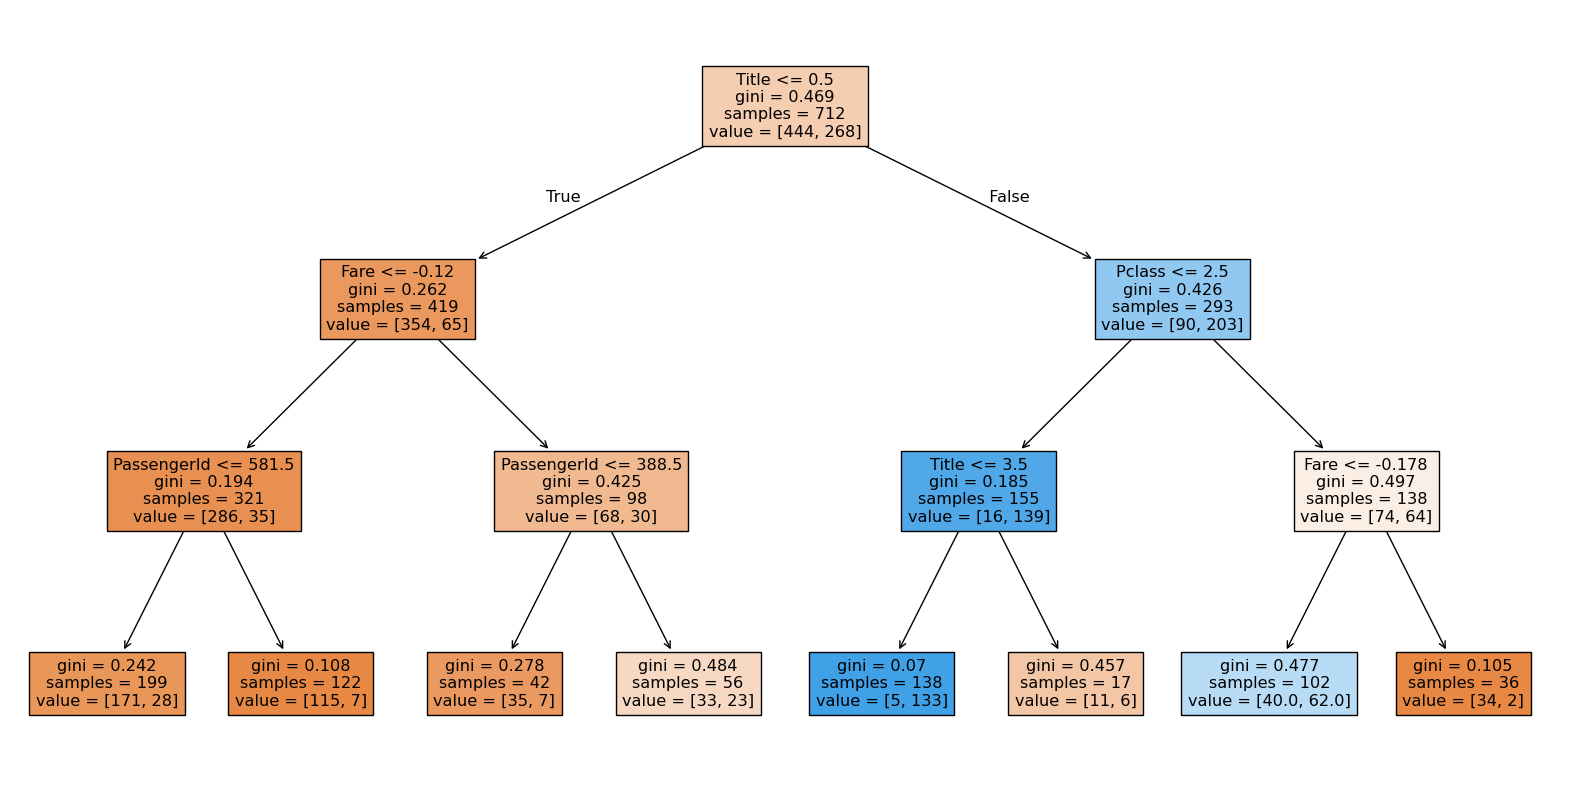

In [61]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=3) # Keep it shallow to see the logic
tree_model.fit(X_train, y_train)

# Pro Tip: You can visualize this!
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X_train.columns, filled=True)
plt.show()

In [62]:
print(f"Decision Tree Accuracy: {tree_model.score(X_test, y_test):.2%}")

Decision Tree Accuracy: 81.56%
